In [8]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [9]:
#Cargar la base de datos depurada
df = pd.read_csv('Leads_Reales_Depurados.csv')

In [10]:
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1%,72%
1,2024,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5%,72%
2,2024,4,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8%,69%
3,2024,5,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7%,65%
4,2024,6,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0%,64%


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   28 non-null     int64  
 1   Mes                   28 non-null     int64  
 2   Total                 28 non-null     float64
 3   Ilocalizable          28 non-null     float64
 4   No Contesta           28 non-null     float64
 5   D. Incorrectos        28 non-null     float64
 6   Duplicados            28 non-null     float64
 7   Efectivos             28 non-null     float64
 8   Abiertos              28 non-null     float64
 9   Ventas                28 non-null     float64
 10  Conversion            28 non-null     str    
 11  Efectividad de Leads  28 non-null     str    
dtypes: float64(8), int64(2), str(2)
memory usage: 2.8 KB


In [12]:
df.isnull().sum()

Año                     0
Mes                     0
Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [13]:
#Definir las variables de Leads
variables_leads = [
    'Total',
    'Ilocalizable',
    'No Contesta',
    'D. Incorrectos',
    'Duplicados',
    'Efectivos',
    'Abiertos',
    'Ventas'
]

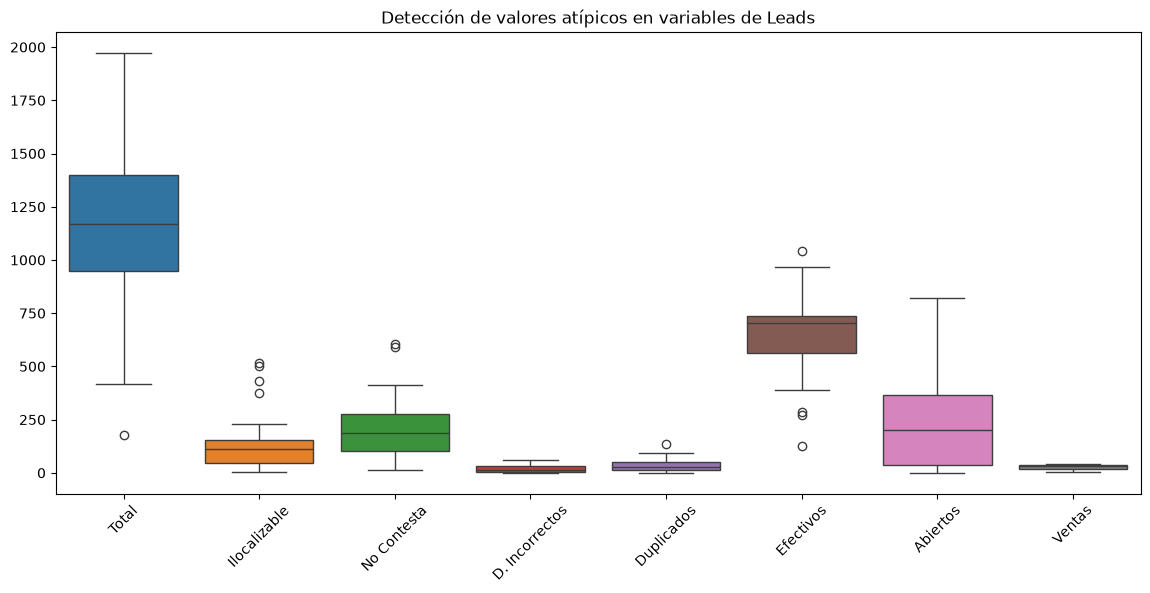

In [14]:
#Revisar posibles valores atípicos
plt.figure(figsize=(14, 6))

sns.boxplot(data=df[variables_leads])

plt.xticks(rotation=45)
plt.title('Detección de valores atípicos en variables de Leads')
plt.show()

In [15]:
#Detectar valores atípicos con el método IQR
for columna in variables_leads:

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(columna, ':', len(outliers), 'outliers')

Total : 1 outliers
Ilocalizable : 4 outliers
No Contesta : 2 outliers
D. Incorrectos : 0 outliers
Duplicados : 1 outliers
Efectivos : 4 outliers
Abiertos : 0 outliers
Ventas : 0 outliers


In [16]:
#Calcular la matriz de correlación
correlacion = df[variables_leads].corr()

correlacion.round(2)

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
Total,1.00,0.59,0.64,0.45,0.26,0.81,0.53,0.53
Ilocalizable,0.59,1.00,0.44,0.29,-0.16,0.25,-0.05,-0.11
No Contesta,0.64,0.44,1.00,-0.04,0.01,0.38,0.01,0.22
D. Incorrectos,0.45,0.29,-0.04,1.00,0.29,0.47,0.38,0.14
Duplicados,0.26,-0.16,0.01,0.29,1.00,0.47,0.34,0.45
Efectivos,0.81,0.25,0.38,0.47,0.47,1.00,0.50,0.65
Abiertos,0.53,-0.05,0.01,0.38,0.34,0.50,1.00,0.75
Ventas,0.53,-0.11,0.22,0.14,0.45,0.65,0.75,1.00


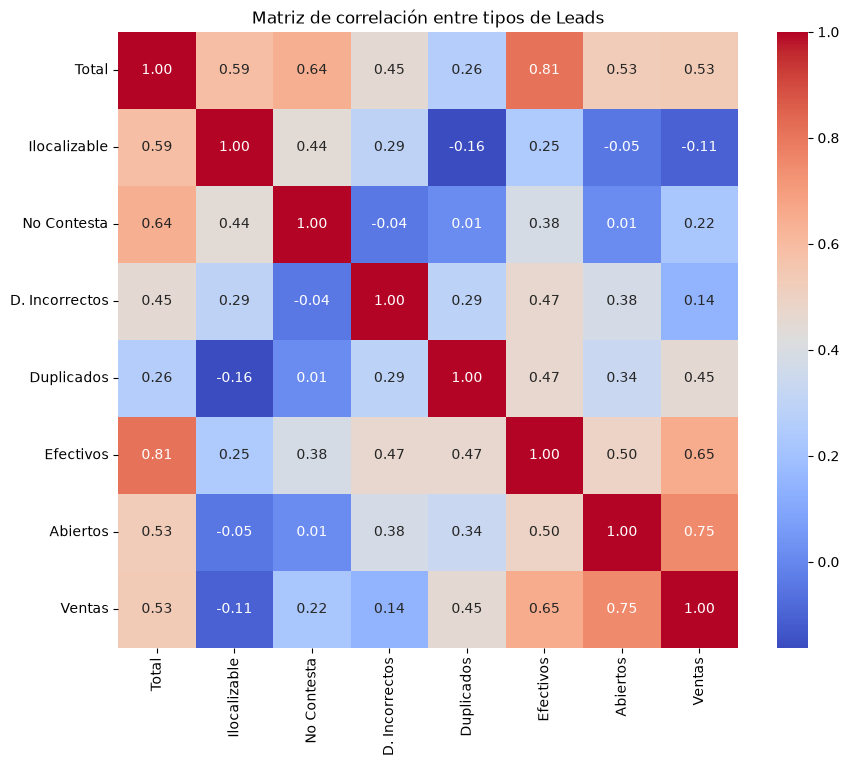

In [17]:
#Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación entre tipos de Leads')
plt.show()

In [18]:
#Definir variable independiente y dependiente
X = df[['Total']]
y = df['Efectivos']

In [19]:
#Crear y entrenar el modelo
modelo = LinearRegression()

modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.41]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,202.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [20]:
#Obtener resultados del modelo
print('Pendiente:', modelo.coef_[0])
print('Intercepto:', modelo.intercept_)
print('R cuadrada:', modelo.score(X, y))

Pendiente: 0.40783245011872216
Intercepto: 202.2052774381205
R cuadrada: 0.6593449223982557


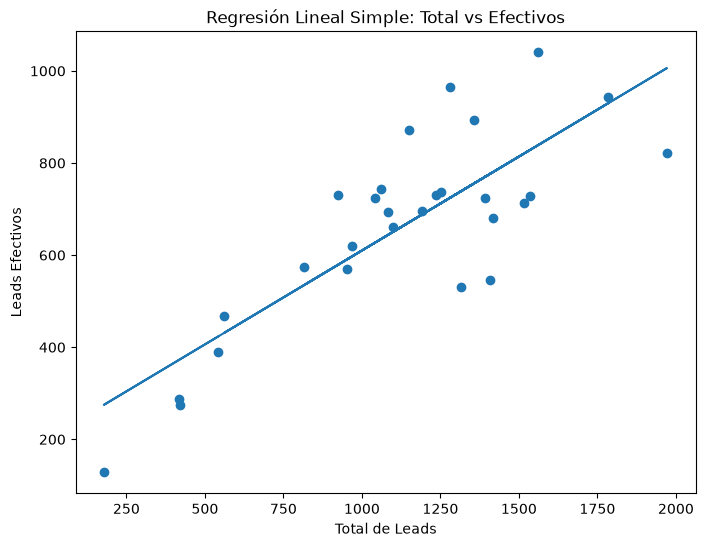

In [21]:
#Gráfica de Regresión Lineal Simple

plt.figure(figsize=(8, 6))

plt.scatter(df['Total'], df['Efectivos'])

plt.plot(
    df['Total'],
    modelo.predict(X)
)

plt.xlabel('Total de Leads')
plt.ylabel('Leads Efectivos')
plt.title('Regresión Lineal Simple: Total vs Efectivos')

plt.show()

In [22]:
#Definir variable independiente y dependiente
X2 = df[['Abiertos']]
y2 = df['Ventas']

In [23]:
#Crear y entrenar el segundo modelo
modelo2 = LinearRegression()

modelo2.fit(X2, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Abiertos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
#Obtener resultados del segundo modelo
print('Pendiente:', modelo2.coef_[0])
print('Intercepto:', modelo2.intercept_)
print('R cuadrada:', modelo2.score(X2, y2))

Pendiente: 0.035334779054580726
Intercepto: 18.126805081456112
R cuadrada: 0.5663330934367705


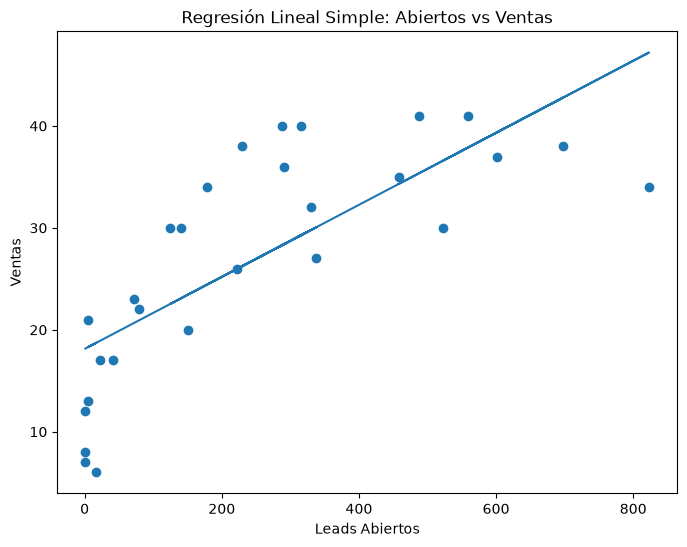

In [25]:
#Gráfica de Regresión Lineal Simple

plt.figure(figsize=(8, 6))

plt.scatter(df['Abiertos'], df['Ventas'])

plt.plot(
    df['Abiertos'],
    modelo2.predict(X2)
)

plt.xlabel('Leads Abiertos')
plt.ylabel('Ventas')
plt.title('Regresión Lineal Simple: Abiertos vs Ventas')

plt.show()

In [26]:
#Definir variable independiente y dependiente
X3 = df[['Efectivos']]
y3 = df['Ventas']

In [27]:
#Crear y entrenar el tercer modelo
modelo3 = LinearRegression()

modelo3.fit(X3, y3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.353
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [28]:
#Obtener resultados del tercer modelo
print('Pendiente:', modelo3.coef_[0])
print('Intercepto:', modelo3.intercept_)
print('R cuadrada:', modelo3.score(X3, y3))

Pendiente: 0.034251442714140455
Intercepto: 4.353440459708139
R cuadrada: 0.4288771119533773


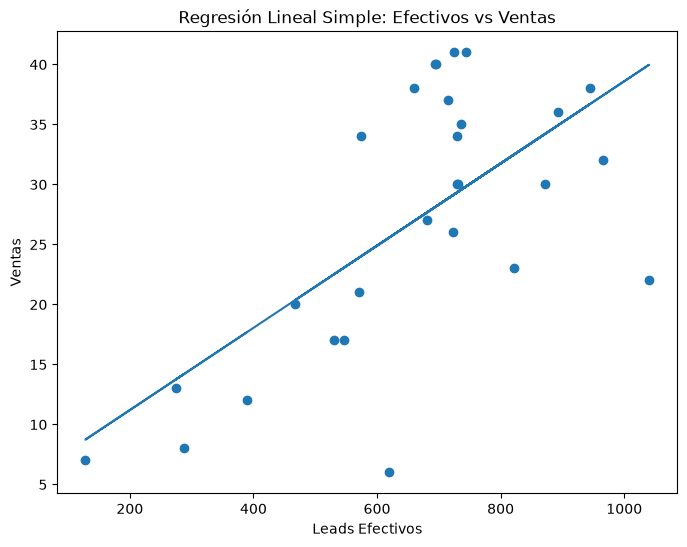

In [29]:
#Gráfica de Regresión Lineal Simple

plt.figure(figsize=(8, 6))

plt.scatter(df['Efectivos'], df['Ventas'])

plt.plot(
    df['Efectivos'],
    modelo3.predict(X3)
)

plt.xlabel('Leads Efectivos')
plt.ylabel('Ventas')
plt.title('Regresión Lineal Simple: Efectivos vs Ventas')

plt.show()

In [30]:
#Resumen de los modelos de Regresión Lineal Simple

resumen_modelos = pd.DataFrame({
    'Modelo': [
        'Total vs Efectivos',
        'Abiertos vs Ventas',
        'Efectivos vs Ventas'
    ],
    
    'Correlación': [
        df['Total'].corr(df['Efectivos']),
        df['Abiertos'].corr(df['Ventas']),
        df['Efectivos'].corr(df['Ventas'])
    ],
    
    'Pendiente': [
        modelo.coef_[0],
        modelo2.coef_[0],
        modelo3.coef_[0]
    ],
    
    'Intercepto': [
        modelo.intercept_,
        modelo2.intercept_,
        modelo3.intercept_
    ],
    
    'R cuadrada': [
        modelo.score(X, y),
        modelo2.score(X2, y2),
        modelo3.score(X3, y3)
    ]
})

resumen_modelos.round(3)

,Modelo,Correlación,Pendiente,Intercepto,R cuadrada
0,Total vs Efectivos,0.812,0.408,202.205,0.659
1,Abiertos vs Ventas,0.753,0.035,18.127,0.566
2,Efectivos vs Ventas,0.655,0.034,4.353,0.429
